In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import matplotlib.pyplot as plt

In [66]:
# --- Cargar dataset ---
df = pd.read_csv("GSHA_ATLAS.csv")

# Suponemos que 'gwt_cm_cav' es la columna a predecir
X = df.drop(['HYRIV_ID','Sttn_Nm','gwt_cm_cav'], axis=1).values  # todas las columnas menos ID y target
y = df['gwt_cm_cav'].values  # target

#Sttn_Nm → Station Name → Nombre de la estación o punto de medición.
#HYRIV_ID → Hydro River ID → Identificador único del río o cuenca hidrográfica.
#ele_mt_uav → Elevation (m) → Elevación media sobre el nivel del mar.
#slp_dg_uav → Slope (°) → Pendiente media en grados.
#sgr_dk_rav → Stream gradient → Gradiente del cauce (pendiente relativa del río).
#inu_pc_ult → Irrigated area (%) → Porcentaje de área irrigada.
#gwt_cm_cav → Groundwater table (cm) → Profundidad del nivel freático (tu y).
#glc_cl_cmj → Glacier class → Clase/categoría de glaciares.
#pnv_cl_cmj → Potential Natural Vegetation class → Vegetación natural potencial.
#wet_pc_u01 → Wetland % (class 01) → Porcentaje de humedales tipo 01.
#wet_pc_u02 → Wetland % (class 02) → Porcentaje de humedales tipo 02.
#wet_pc_u03 → Wetland % (class 03) → Porcentaje de humedales tipo 03.
#wet_pc_u04 → Wetland % (class 04) → Porcentaje de humedales tipo 04.
#wet_pc_u05 → Wetland % (class 05) → Porcentaje de humedales tipo 05.
#wet_pc_u06 → Wetland % (class 06) → Porcentaje de humedales tipo 06.
#wet_pc_u07 → Wetland % (class 07) → Porcentaje de humedales tipo 07.
#wet_pc_u08 → Wetland % (class 08) → Porcentaje de humedales tipo 08.
#wet_pc_u09 → Wetland % (class 09) → Porcentaje de humedales tipo 09.
#gla_pc_use → Glacier % coverage → Porcentaje de cobertura glaciar.
#prm_pc_use → Permanent snow/ice % → Porcentaje de nieve o hielo permanente.
#cly_pc_uav → Clay % (soil) → Porcentaje de arcilla en el suelo.
#slt_pc_uav → Silt % (soil) → Porcentaje de limo en el suelo.
#snd_pc_uav → Sand % (soil) → Porcentaje de arena en el suelo.
#lit_cl_cmj → Lithology class → Clase de litología (tipo de roca predominante).
#ero_kh_uav → Erodibility (K factor) → Factor de erodabilidad del suelo (qué tan fácil se erosiona).

# --- Dividir en train/val/test/subset ---
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# --- Crear un pequeño subset de prueba (opcional) ---
X_subset, y_subset = X_train[:50], y_train[:50]

# Revisar shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("X_subset:", X_subset.shape)

print(df[:5])

X_train: (15239, 22)
X_val: (3265, 22)
X_test: (3266, 22)
X_subset: (50, 22)
        Sttn_Nm  HYRIV_ID  ele_mt_uav  slp_dg_uav  sgr_dk_rav  inu_pc_ult  \
0  1104150_GRDC  10004056         762          46           5          15   
1  1104450_GRDC  10001083         390          84          15          15   
2  1104600_GRDC  10002093         950          70          49          56   
3  1104800_GRDC  10001949         649         109          36           0   
4  1107700_GRDC  10009743         760          64          39          15   

   gwt_cm_cav  glc_cl_cmj  pnv_cl_cmj  wet_pc_u01  ...  wet_pc_u07  \
0         412          12          11           0  ...           1   
1         455          16           9           0  ...           0   
2         636          12          11           0  ...           0   
3         414          16          11           0  ...           0   
4         463          12           9           0  ...           0   

   wet_pc_u08  wet_pc_u09  gla_pc_use  

In [67]:
# ===============================
# 5) NORMALIZACIÓN (solo con TRAIN)
# ===============================
def featureNormalize(X_train, X_val=None, X_test=None):
    """
    Normaliza X usando media y desviación estándar de X_train
    """
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    sigma[sigma == 0] = 1.0  # evitar división por cero

    X_train_norm = (X_train - mu) / sigma

    X_val_norm = (X_val - mu) / sigma if X_val is not None else None
    X_test_norm = (X_test - mu) / sigma if X_test is not None else None

    return X_train_norm, X_val_norm, X_test_norm, mu, sigma

In [68]:
X_train_norm, X_val_norm, X_test_norm, mu, sigma = featureNormalize(X_train, X_val, X_test)

In [69]:
# Si quieres, también puedes normalizar y (target) de forma similar
def targetNormalize(y_train, y_val=None, y_test=None):
    mu = np.mean(y_train, axis=0)
    sigma = np.std(y_train, axis=0)
    sigma = 1.0 if sigma==0 else sigma

    y_train_norm = (y_train - mu) / sigma
    y_val_norm = (y_val - mu) / sigma if y_val is not None else None
    y_test_norm = (y_test - mu) / sigma if y_test is not None else None

    return y_train_norm, y_val_norm, y_test_norm, mu, sigma

In [70]:
y_train_norm, y_val_norm, y_test_norm, y_mu, y_sigma = targetNormalize(y_train, y_val, y_test)

In [71]:
class TabularDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)  # para regresión
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = {
    'train': TabularDataset(X_train_norm, y_train_norm),
    'val': TabularDataset(X_val_norm, y_val_norm),
    'test': TabularDataset(X_test_norm, y_test_norm)
}

dataloader = {
    'train': DataLoader(dataset['train'], batch_size=256, shuffle=True),
    'val': DataLoader(dataset['val'], batch_size=1000, shuffle=False),
    'test': DataLoader(dataset['test'], batch_size=1000, shuffle=False)
}

In [72]:

def build_model(D_in=X_train.shape[1], H=16, D_out=1):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    )

In [73]:
def fit(model, dataloader, epochs=200, log_each=10, weight_decay=1e-4, early_stopping=20):
    criterion = nn.MSELoss()  # regresión
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    step = 0

    for e in range(1, epochs+1):
        # --- entrenamiento ---
        model.train()
        batch_losses = []
        for x_b, y_b in dataloader['train']:
            optimizer.zero_grad()
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b.unsqueeze(1))
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss_mean = np.mean(batch_losses)
        train_losses.append(train_loss_mean)

        # --- validación ---
        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b.unsqueeze(1))
                val_batch_losses.append(loss.item())
        val_loss_mean = np.mean(val_batch_losses)
        val_losses.append(val_loss_mean)

        # guardar mejor modelo
        if val_loss_mean < best_val_loss:
            best_val_loss = val_loss_mean
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
        else:
            step += 1

        # Early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs")
            break

        if e % log_each == 0:
            print(f"Epoch {e}/{epochs} train_loss: {train_loss_mean:.5f}, val_loss: {val_loss_mean:.5f}")

    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(train_losses)+1)),
            'train_loss': train_losses, 'val_loss': val_losses}


In [74]:
# --- Entrenamiento ---
model = build_model()
hist = fit(model, dataloader)

Epoch 10/200 train_loss: 0.38187, val_loss: 0.40337
Epoch 20/200 train_loss: 0.35518, val_loss: 0.37619
Epoch 30/200 train_loss: 0.34427, val_loss: 0.37208
Epoch 40/200 train_loss: 0.34160, val_loss: 0.36951
Epoch 50/200 train_loss: 0.33540, val_loss: 0.36616
Epoch 60/200 train_loss: 0.33070, val_loss: 0.36508
Epoch 70/200 train_loss: 0.32538, val_loss: 0.36207
Epoch 80/200 train_loss: 0.32314, val_loss: 0.36117
Epoch 90/200 train_loss: 0.32227, val_loss: 0.36351
Entrenamiento detenido en epoch 99 por no mejorar en 20 epochs


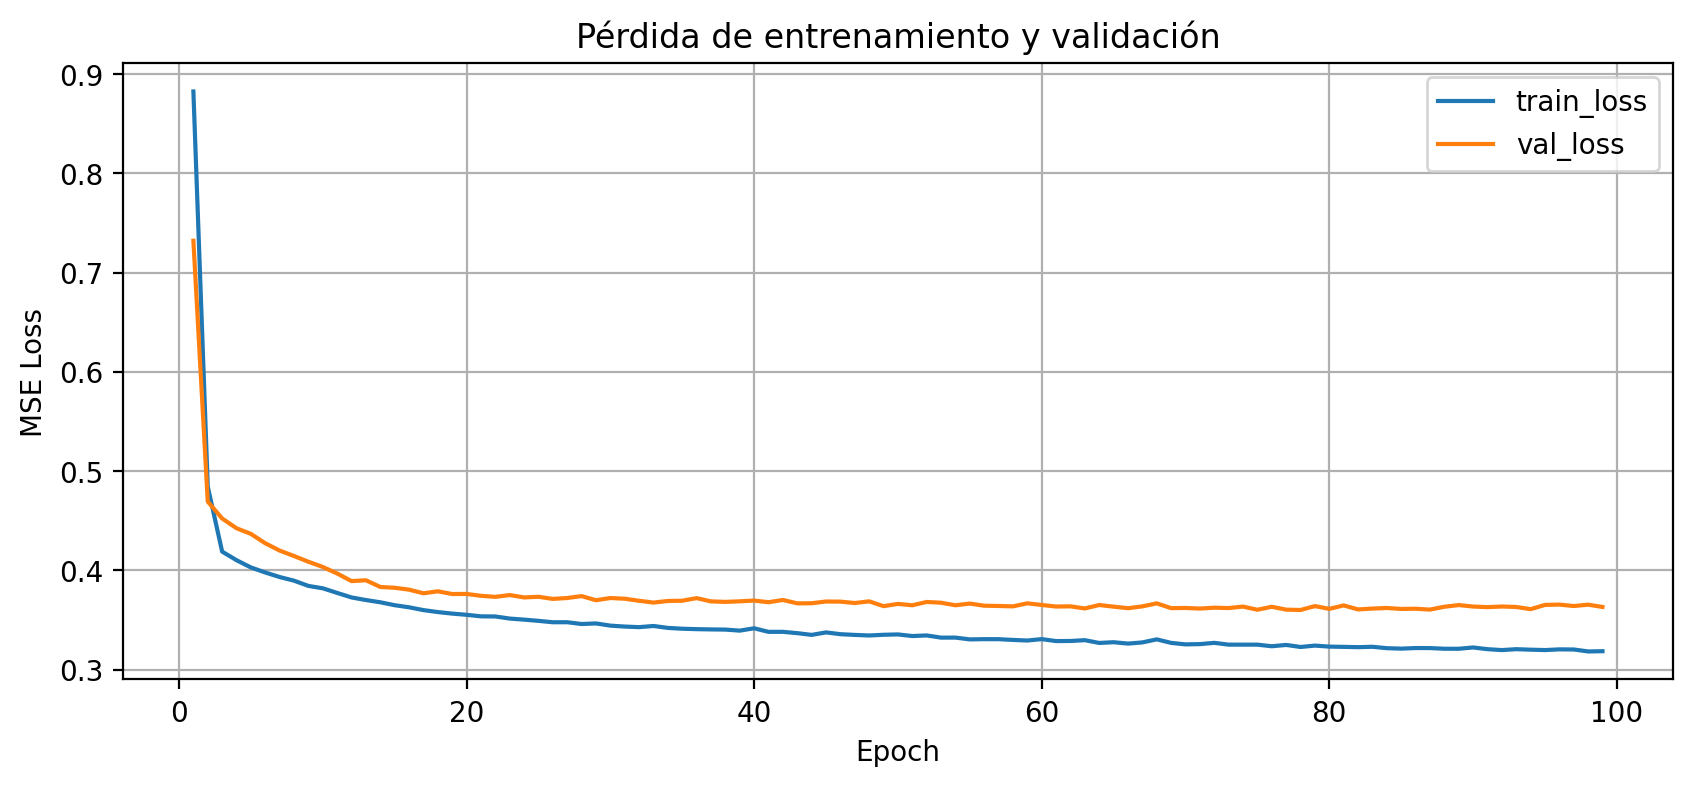

In [75]:
# --- GRAFICAR ---
# hist es el diccionario que devuelve tu función fit
df_hist = pd.DataFrame(hist)

fig = plt.figure(dpi=200, figsize=(10,4))

# --- Pérdida ---
ax = plt.subplot(1,1,1)
df_hist.plot(x='epoch', y=['train_loss', 'val_loss'], grid=True, ax=ax)
ax.set_title("Pérdida de entrenamiento y validación")
ax.set_ylabel("MSE Loss")
ax.set_xlabel("Epoch")

plt.show()

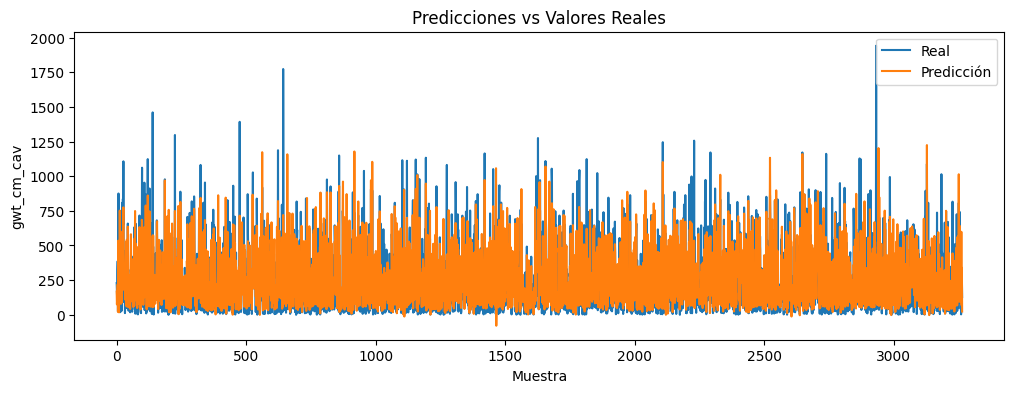

In [76]:
# modelo en modo evaluación
model.eval()
y_preds, y_trues = [], []

with torch.no_grad():
    for x_b, y_b in dataloader['test']:
        y_pred = model(x_b)
        y_preds.append(y_pred)
        y_trues.append(y_b)

# unir batches
y_preds = np.concatenate([y.cpu().numpy() for y in y_preds], axis=0)
y_trues = np.concatenate([y.cpu().numpy() for y in y_trues], axis=0)

# desnormalizar si normalizaste Y
y_preds_real = y_preds * y_sigma + y_mu
y_trues_real = y_trues * y_sigma + y_mu


plt.figure(figsize=(12,4))
plt.plot(y_trues_real, label='Real')
plt.plot(y_preds_real, label='Predicción')
plt.legend()
plt.title("Predicciones vs Valores Reales")
plt.xlabel("Muestra")
plt.ylabel("gwt_cm_cav")
plt.show()

In [77]:
#Prediccion:
# Supongamos que tomamos la primera fila del set de test
example_row = X_test[0]        # features
example_y_real = y_test[0]     # valor real de y

example_row_norm = (example_row - mu) / sigma
example_row_norm = torch.tensor(example_row_norm, dtype=torch.float32).unsqueeze(0)  # forma [1, num_features]

model.eval()
with torch.no_grad():
    y_pred_norm = model(example_row_norm)
    
# Desnormalizar para obtener valor real
y_pred_real = y_pred_norm.numpy() * y_sigma + y_mu

y_pred_real = y_pred_norm.item() * y_sigma + y_mu
print(f"Valor real de y: {example_y_real}, Predicción: {y_pred_real:.2f}")

Valor real de y: 229, Predicción: 166.78
